# basic inspecting of attention patterns

we load a `gpt2-small`, throw in some text, and peek at the attention patterns of a few heads.

In [1]:
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

In [2]:
MODEL: HookedTransformer = HookedTransformer.from_pretrained("gpt2-small")

Loaded pretrained model gpt2-small into HookedTransformer


In [ ]:
prompt: str = "The quick brown fox jumps over the other quick brown fox."
logits, cache = MODEL.run_with_cache(prompt)
assert MODEL.tokenizer is not None
prompt_tokens: list[str] = MODEL.tokenizer.tokenize(prompt)
prompt_tokens = [x.replace("Ġ", " ") for x in prompt_tokens]
print(prompt_tokens)

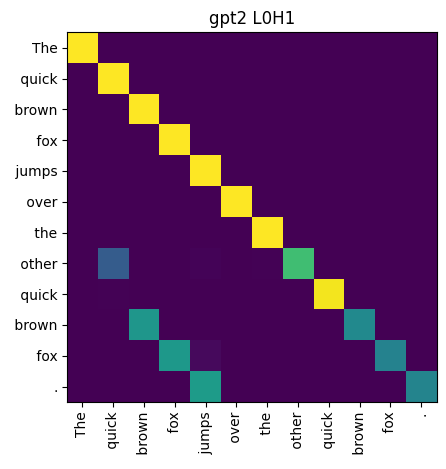

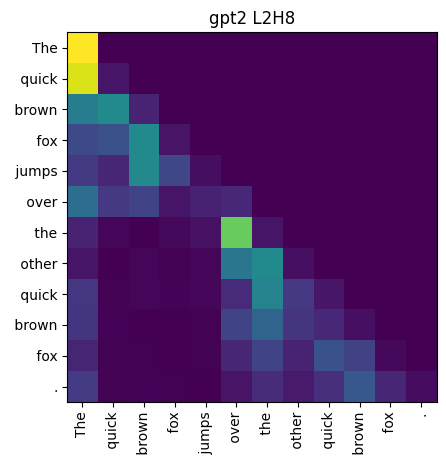

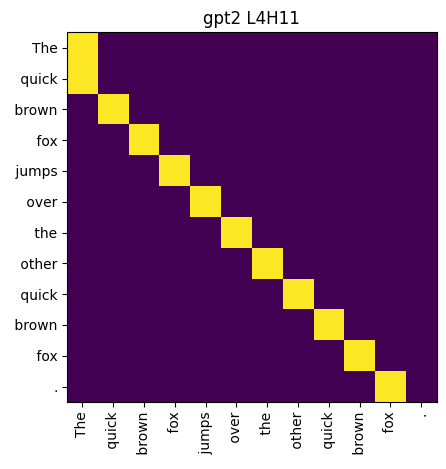

In [4]:
show_heads: set[tuple[int, int]] = {
	(0, 1),
	(2, 8),
	(4, 11),
}

for layer_idx in range(MODEL.cfg.n_layers):
	for head_idx in range(MODEL.cfg.n_heads):
		if (layer_idx, head_idx) not in show_heads:
			continue
		pattern = cache[f"blocks.{layer_idx}.attn.hook_pattern"][0, head_idx]
		pattern = pattern[:-1, :-1]  # trim end of text token
		fig, ax = plt.subplots()
		ax.imshow(pattern.cpu().numpy())
		ax.set_xticks(range(len(prompt_tokens)))
		ax.set_yticks(range(len(prompt_tokens)))
		ax.set_yticklabels(prompt_tokens)
		ax.set_xticklabels(prompt_tokens, rotation=90)
		ax.set_title(f"{MODEL.cfg.model_name} L{layer_idx}H{head_idx}")
		plt.show()